<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Nikhil_Verma_N1217583_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and preprocess the Iris Dataset
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv('bezdekIris.data', names=columns, sep=',')

In [82]:
df.head(11)

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [83]:
df.tail(11)

,sepal_length,sepal_width,petal_length,petal_width,class
139,6.9,3.1,5.4,2.1,Iris-virginica
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [84]:
df.shape

(150, 5)

In [85]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'], dtype='object')

In [86]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
class,object


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [88]:
df.describe(include = 'all')

,sepal_length,sepal_width,petal_length,petal_width,class
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [91]:
# Check for duplicate values
print('Duplicated Values:',df.duplicated().sum())

Duplicated Values: 1


In [28]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64


In [5]:
# Features and target
X = df.drop('class', axis=1)
y = df['class']

In [63]:
# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [92]:
# Encode labels for evaluation
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [31]:
# Split data for Tasks 1-3 (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=3)
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(X_scaled.values.reshape(-1, 2, 2, 1), y_onehot, test_size=0.2, random_state=42)

In [32]:
# Store accuracies for comparison
results = []

# Task 1: MLP Classifier

In [67]:
print("Task 1: MLP Classifier")
mlp = MLPClassifier(
    hidden_layer_sizes=(30, 15, 20),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    verbose=True
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"Task 1 - MLP Test Accuracy: {mlp_accuracy:.2f}")
results.append(('MLP (Task 1)', 'Accuracy', mlp_accuracy))

Task 1: MLP Classifier
Iteration 1, loss = 1.15282898
Iteration 2, loss = 1.14968455
Iteration 3, loss = 1.14658901
Iteration 4, loss = 1.14353984
Iteration 5, loss = 1.14056690
Iteration 6, loss = 1.13767043
Iteration 7, loss = 1.13484781
Iteration 8, loss = 1.13208327
Iteration 9, loss = 1.12937108
Iteration 10, loss = 1.12669870
Iteration 11, loss = 1.12407048
Iteration 12, loss = 1.12144680
Iteration 13, loss = 1.11888380
Iteration 14, loss = 1.11642137
Iteration 15, loss = 1.11411624
Iteration 16, loss = 1.11194754
Iteration 17, loss = 1.10978732
Iteration 18, loss = 1.10767382
Iteration 19, loss = 1.10559905
Iteration 20, loss = 1.10351559
Iteration 21, loss = 1.10139389
Iteration 22, loss = 1.09922831
Iteration 23, loss = 1.09701239
Iteration 24, loss = 1.09473772
Iteration 25, loss = 1.09240892
Iteration 26, loss = 1.09002601
Iteration 27, loss = 1.08760327
Iteration 28, loss = 1.08514160
Iteration 29, loss = 1.08265217
Iteration 30, loss = 1.08012309
Iteration 31, loss = 1.077

In [76]:
print(f"Task 1 - MLP Test Accuracy: {mlp_accuracy:.2f}")
print("\nTask 1 - MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))
results.append(('MLP (Task 1)', 'Accuracy', mlp_accuracy))

Task 1 - MLP Test Accuracy: 1.00

Task 1 - MLP Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Confusion matrix

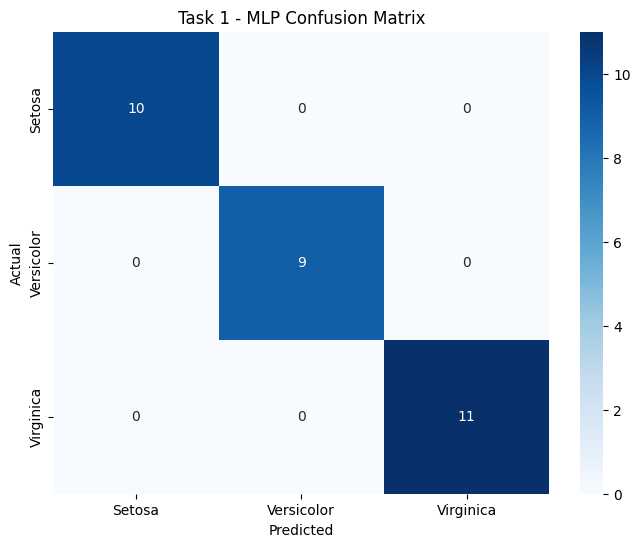

In [40]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Task 1 - MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Task - 2: Random Forest Classifier

In [44]:
print("Task 2: Random Forest Classifier:")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy:.2f}")
results.append(('Random Forest (Task 2)', 'Accuracy', rf_accuracy))

Task 2: Random Forest Classifier:
Random Forest Test Accuracy: 1.00


In [45]:
# Classification report
print("\nTask 2 - Random Forest Classification Report:")
print(classification_report(y_pred_rf, y_pred_rf))


Task 2 - Random Forest Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



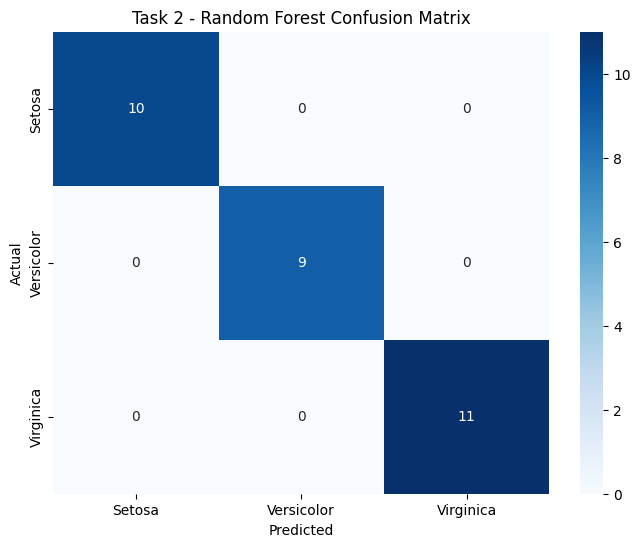

In [46]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Task 2 - Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Task 2 - Feature Importance:
        Feature  Importance
2  petal_length    0.439994
3   petal_width    0.421522
0  sepal_length    0.108098
1   sepal_width    0.030387


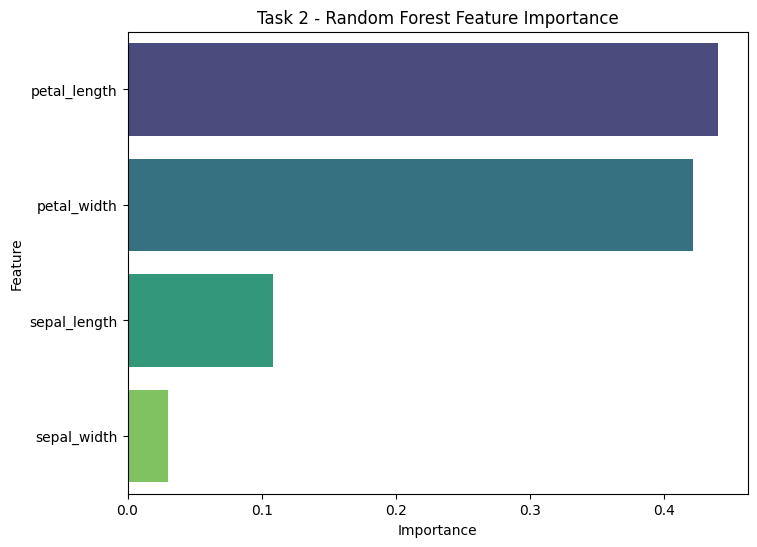

In [79]:
# Feature importance:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nTask 2 - Feature Importance:")
print(feature_importance)
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Task 2 - Random Forest Feature Importance')
plt.show()

# Task - 3: Deep Convolution Nerual Network

In [48]:
print("Task 3: Deep CNN")
model = Sequential([
    Conv2D(16, (2, 2), activation='relu', input_shape=(2, 2, 1), padding='same'),
    Conv2D(32, (2, 2), activation='relu', padding='same'),
    Conv2D(64, (2, 2), activation='relu', padding='same'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_cnn, y_train_cnn, epochs=50, batch_size=16, validation_split=0.2, verbose=1)
y_test_pred = model.predict(X_test_cnn)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_true = np.argmax(y_test_cnn, axis=1)
cnn_accuracy = accuracy_score(y_test_true, y_test_pred_classes)
print(f"Task 3 - CNN Test Accuracy: {cnn_accuracy:.4f}")
results.append(('CNN (Task 3)', 'Accuracy', cnn_accuracy))


=== Task 3: Deep CNN ===


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.1975 - loss: 1.0982 - val_accuracy: 0.5833 - val_loss: 1.0657
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4635 - loss: 1.0693 - val_accuracy: 0.7083 - val_loss: 1.0317
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5693 - loss: 1.0476 - val_accuracy: 0.7083 - val_loss: 0.9844
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6115 - loss: 1.0080 - val_accuracy: 0.7083 - val_loss: 0.9184
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6080 - loss: 0.9422 - val_accuracy: 0.7083 - val_loss: 0.8147
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6506 - loss: 0.8545 - val_accuracy: 0.7083 - val_loss: 0.7164
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6369 - loss: 0.7629 - val_accuracy: 0.7500 - val_loss: 0.6210
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7704 - loss: 0.5991 - val_accuracy: 0.9583 - val_loss: 0.5411


In [75]:
# Classification report
print("\nTask 3 - CNN Classification Report:")
print(classification_report(y_test_true, y_test_pred_classes, target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']))
results.append(('CNN (Task 3)', 'Accuracy', cnn_accuracy))


Task 3 - CNN Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



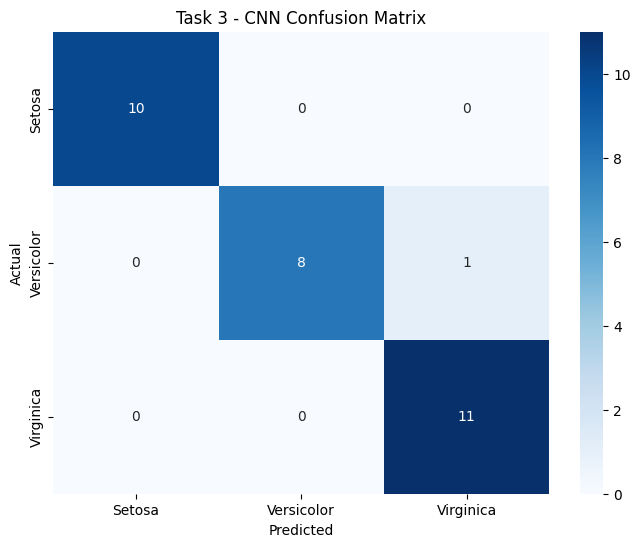

In [73]:
# Confusion matrix
cm_cnn = confusion_matrix(y_test_true, y_test_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Task 3 - CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

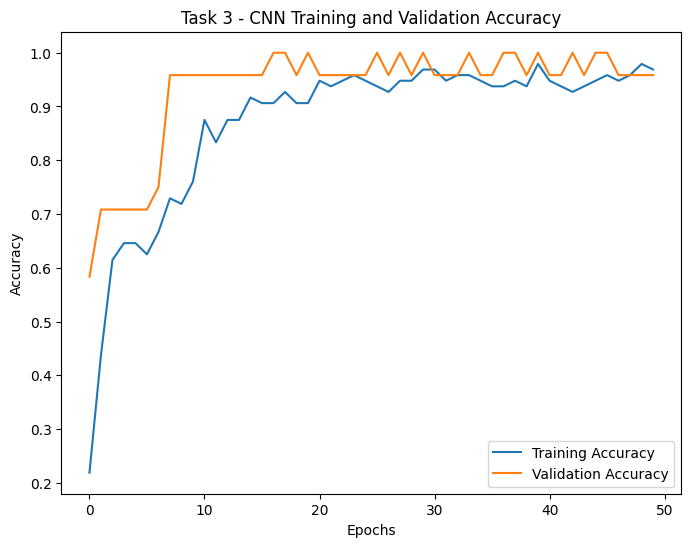

In [51]:
# Training history
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 3 - CNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Task - 4: K-Mean Clustering

In [53]:
print("Task 4: K-means Clustering")
inertia = []
silhouette_scores = []
K = range(2, 7)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    if k > 1:
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

Task 4: K-means Clustering


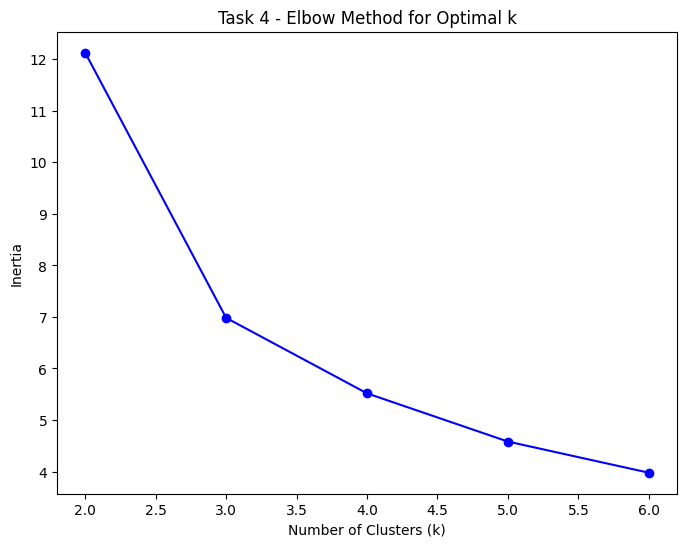

In [54]:
# Plot elbow curve:
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.title('Task 4 - Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

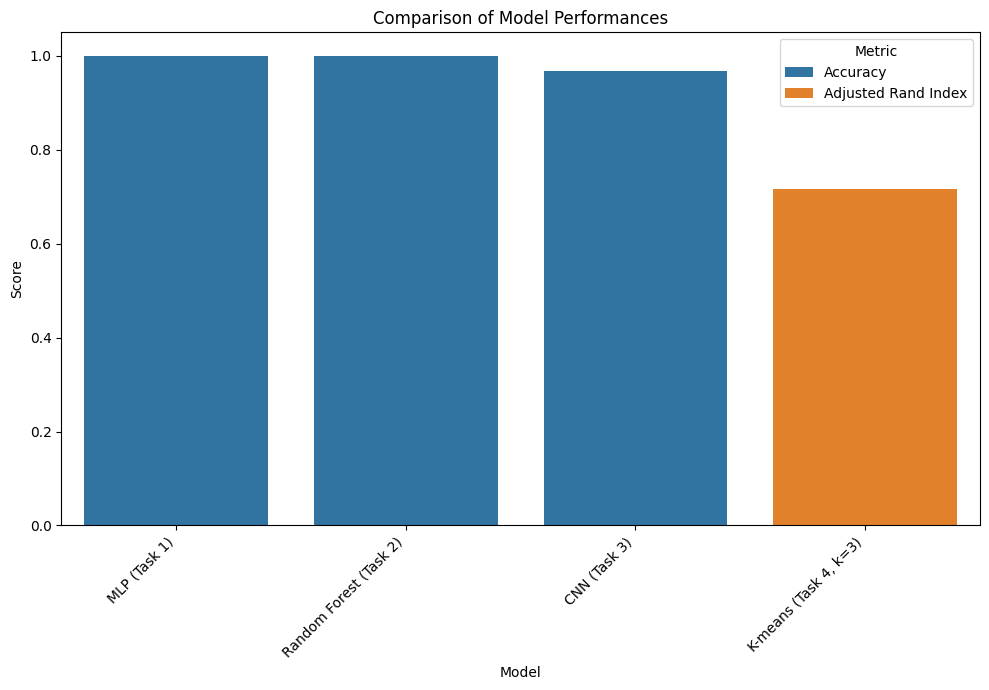

In [62]:
# Visualize the comparison table
plt.figure(figsize=(10, 7))
sns.barplot(x='Model', y='Value', hue='Metric', data=comparison_table)
plt.title('Comparison of Model Performances')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [81]:
# Apply K-means with optimal k=3

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_
ari = adjusted_rand_score(y_encoded, cluster_labels)
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Task 4 - K-means Adjusted Rand Index (k={optimal_k}): {ari:.4f}")
print(f"Task 4 - K-means Silhouette Score (k={optimal_k}): {sil_score:.4f}")
results.append((f'K-means (Task 4, k={optimal_k})', 'Adjusted Rand Index', ari))

Task 4 - K-means Adjusted Rand Index (k=3): 0.7163
Task 4 - K-means Silhouette Score (k=3): 0.5048


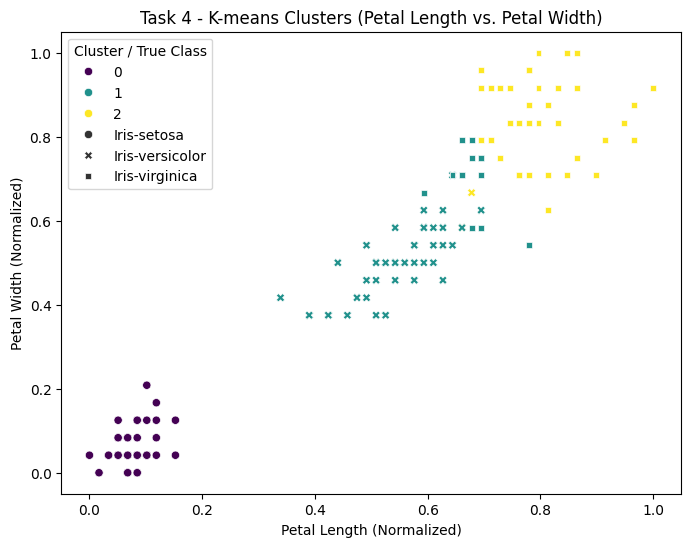

In [57]:
# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled['petal_length'], y=X_scaled['petal_width'], hue=cluster_labels, palette='viridis', style=y)
plt.title('Task 4 - K-means Clusters (Petal Length vs. Petal Width)')
plt.xlabel('Petal Length (Normalized)')
plt.ylabel('Petal Width (Normalized)')
plt.legend(title='Cluster / True Class')
plt.show()

In [58]:
# Final comparison table
comparison_table = pd.DataFrame(results, columns=['Model', 'Metric', 'Value'])
print("\nFinal Comparison Table:")
print(comparison_table)


Final Comparison Table:
                    Model               Metric     Value
0            MLP (Task 1)             Accuracy  1.000000
1  Random Forest (Task 2)             Accuracy  1.000000
2  Random Forest (Task 2)             Accuracy  1.000000
3            MLP (Task 1)             Accuracy  1.000000
4  Random Forest (Task 2)             Accuracy  1.000000
5  Random Forest (Task 2)             Accuracy  1.000000
6  Random Forest (Task 2)             Accuracy  1.000000
7  Random Forest (Task 2)             Accuracy  1.000000
8            CNN (Task 3)             Accuracy  0.966667
9   K-means (Task 4, k=3)  Adjusted Rand Index  0.716342


# Thank you